### Feature Importance Using [SHAP](https://shap.readthedocs.io/en/latest/) Library

In [2]:
import os
import sys
import random
import pandas as pd
import numpy as np
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    f1_score, precision_score, recall_score, accuracy_score
)


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/traitlets/config/applicat

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/runpy.py", line 197, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/runpy.py", line 87, in _run_code
    exec(code, run_globals)
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/ipykernel_launcher.py", line 16, in <module>
    app.launch_new_instance()
  File "/sw/pkgs/arc/python3.9-anaconda/2021.11/lib/python3.9/site-packages/traitlets/config/applicat

AttributeError: _ARRAY_API not found

In [3]:
!{sys.executable} -m pip install torch

Defaulting to user installation because normal site-packages is not writeable


In [4]:
pip install shap

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [26]:
import torch
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
from torchvision.models.resnet import Bottleneck

import shap

### Pneumonia

In [20]:
# --- CLUSTER PATHS ---
# Root of MIMIC project on the cluster (adjust if needed)
PROJECT_ROOT = Path("/nfs/turbo/si-acastel/mimic-project")

# the MIMIC-CXR JPGs
IMAGES_ROOT = PROJECT_ROOT / "data_raw/mimic-cxr-jpg_2_1_0_gcs" / "files"

# (this should be wherever ResNet_*_v1.ipynb lives)
WORK_DIR = "."  # <-- adjust to your real folder name

# Change into that directory so relative paths match the training notebook
os.chdir(WORK_DIR)
print("Working directory:", os.getcwd())

# Paths reused from training notebook
CHECKPOINT_DIR = Path("checkpoints_resnet50_pneumonia")
TEST_MANIFEST_PATH = Path("resnet50_pneumonia_test_manifest.csv")

print("IMAGES_ROOT:", IMAGES_ROOT)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR.resolve())
print("TEST_MANIFEST_PATH:", TEST_MANIFEST_PATH.resolve())

# --- Sanity checks so we fail early if something's off ---
assert IMAGES_ROOT.exists(), f"IMAGES_ROOT does not exist: {IMAGES_ROOT}"
assert CHECKPOINT_DIR.exists(), f"CHECKPOINT_DIR does not exist: {CHECKPOINT_DIR}"
assert TEST_MANIFEST_PATH.exists(), f"TEST_MANIFEST_PATH does not exist: {TEST_MANIFEST_PATH}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Working directory: /home/simbody
IMAGES_ROOT: /nfs/turbo/si-acastel/mimic-project/data_raw/mimic-cxr-jpg_2_1_0_gcs/files
CHECKPOINT_DIR: /home/simbody/checkpoints_resnet50_pneumonia
TEST_MANIFEST_PATH: /home/simbody/resnet50_pneumonia_test_manifest.csv
device: cuda


#### Perform pre-training model bulding steps but use saved artifacts instead of re-training model

In [21]:
class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row["image_path"])

        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")
        label = float(row["pneumonia"])

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.float32)

In [22]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    )
])

In [23]:
df = pd.read_csv(TEST_MANIFEST_PATH)
print(df.head())
print(df.columns)

                                          image_path  pneumonia
0  /nfs/turbo/si-acastel/mimic-project/data_raw/m...          1
1  /nfs/turbo/si-acastel/mimic-project/data_raw/m...          1
2  /nfs/turbo/si-acastel/mimic-project/data_raw/m...          0
3  /nfs/turbo/si-acastel/mimic-project/data_raw/m...          1
4  /nfs/turbo/si-acastel/mimic-project/data_raw/m...          1
Index(['image_path', 'pneumonia'], dtype='object')


In [24]:
test_df = df.copy()
test_ds = CXRDataset(test_df, transform=preprocess)

train_df_for_bg = df.copy()
train_ds = CXRDataset(train_df_for_bg, transform=preprocess)

In [25]:
def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model.to(device)

# Pick one checkpoint file from the directory
checkpoint_files = sorted(CHECKPOINT_DIR.glob("*.pth")) + sorted(CHECKPOINT_DIR.glob("*.pt"))
print("Found checkpoints:")
for ck in checkpoint_files:
    print("-", ck)

assert checkpoint_files, "No checkpoint files found in CHECKPOINT_DIR!"

# Choose one (e.g., best fold or final)
checkpoint_path = checkpoint_files[0]  # or manually pick the best one
print("Using checkpoint:", checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location=device)

model = build_model()

# Handle different save styles
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("Model loaded and set to eval mode.")

Found checkpoints:
- checkpoints_resnet50_pneumonia/resnet50_pneumonia_fold1_best.pth
- checkpoints_resnet50_pneumonia/resnet50_pneumonia_fold2_best.pth
- checkpoints_resnet50_pneumonia/resnet50_pneumonia_fold3_best.pth
- checkpoints_resnet50_pneumonia/resnet50_pneumonia_fold4_best.pth
- checkpoints_resnet50_pneumonia/resnet50_pneumonia_fold5_best.pth
Using checkpoint: checkpoints_resnet50_pneumonia/resnet50_pneumonia_fold1_best.pth
Model loaded and set to eval mode.


In [27]:
# Solutions from pytorch forums for "BackwardHookFunctionBackward" error
def make_resnet_shap_safe(model: nn.Module) -> nn.Module:
    # 1. Make all ReLUs non-in-place
    for m in model.modules():
        if isinstance(m, nn.ReLU):
            m.inplace = False

    # 2. Replace Bottleneck.forward to avoid in-place residual add
    def bottleneck_forward_no_inplace(self, x):
        # Standard bottleneck logic, but using out-of-place addition
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        # IMPORTANT: out-of-place add instead of `out += identity`
        out = out + identity
        out = self.relu(out)
        return out

    for m in model.modules():
        if isinstance(m, Bottleneck):
            # Monkey-patch this instance's forward method
            m.forward = bottleneck_forward_no_inplace.__get__(m, m.__class__)

    return model

In [28]:
model = build_model()

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = make_resnet_shap_safe(model)

model.to(device)
model.eval()

print("Model loaded, patched for SHAP, and set to eval mode.")

Model loaded, patched for SHAP, and set to eval mode.


In [29]:
# Wrap model in sigmoid function
class WrappedModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base = base_model

    def forward(self, x):
        logits = self.base(x)
        probs = torch.sigmoid(logits)
        return probs

wrapped_model = WrappedModel(model).to(device)
wrapped_model.eval()

WrappedModel(
  (base): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (downsample): Sequential(
          (0): Conv2d(64, 256, k

In [30]:
# after building base_model / resnet50
for m in model.modules():
    if isinstance(m, nn.ReLU):
        m.inplace = False

wrapped_model = WrappedModel(model).to(device)
wrapped_model.eval()

WrappedModel(
  (base): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (downsample): Sequential(
          (0): Conv2d(64, 256, k

In [31]:
BACKGROUND_SIZE = 10
EXPLAIN_SIZE = 5

np.random.seed(42)

# Background from "train" proxy (here: test_df)
background_indices = np.random.choice(len(train_ds), size=min(BACKGROUND_SIZE, len(train_ds)), replace=False)
background_imgs = [train_ds[i][0] for i in background_indices]
background_tensor = torch.stack(background_imgs).to(device)
print("Background tensor shape:", background_tensor.shape)

# Images to explain from test_ds
explain_indices = np.random.choice(len(test_ds), size=min(EXPLAIN_SIZE, len(test_ds)), replace=False)
explain_imgs = [test_ds[i][0] for i in explain_indices]
explain_labels = [test_ds[i][1] for i in explain_indices]

explain_tensor = torch.stack(explain_imgs).to(device)
explain_labels = torch.tensor(explain_labels)
print("Explain tensor shape:", explain_tensor.shape)

Background tensor shape: torch.Size([10, 3, 224, 224])
Explain tensor shape: torch.Size([5, 3, 224, 224])


In [32]:
# https://shap.readthedocs.io/en/latest/generated/shap.GradientExplainer.html
explainer = shap.GradientExplainer(wrapped_model, background_tensor)
shap_values = explainer.shap_values(explain_tensor)

# For single output:
if isinstance(shap_values, list) and len(shap_values) == 1:
    shap_values = shap_values[0]

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (5, 3, 224, 224, 1)


In [33]:
def unnormalize(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406], device=img_tensor.device).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=img_tensor.device).view(3, 1, 1)
    img = img_tensor * std + mean
    img = img.clamp(0, 1)
    return img

explain_imgs_unnorm = []
for i in range(explain_tensor.shape[0]):
    img = unnormalize(explain_tensor[i]).detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))  # (H, W, 3)
    explain_imgs_unnorm.append(img)

explain_imgs_unnorm = np.stack(explain_imgs_unnorm)
print("Explain images (unnorm) shape:", explain_imgs_unnorm.shape)

Explain images (unnorm) shape: (5, 224, 224, 3)


original sv: (5, 3, 224, 224, 1)
after squeeze: (5, 3, 224, 224)
after transpose: (5, 224, 224, 3)
explain_imgs_unnorm: (5, 224, 224, 3)


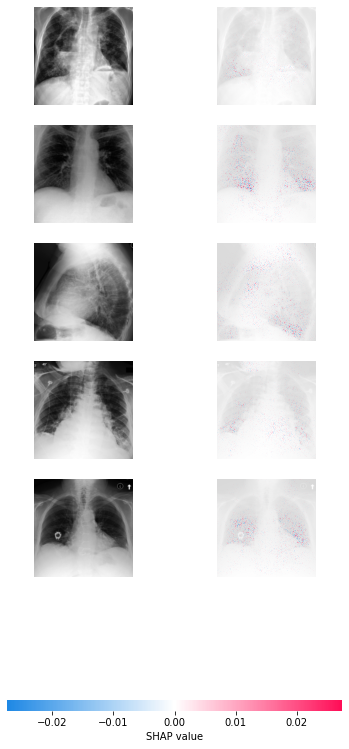

In [41]:
# 1. Extract the SHAP array
if isinstance(shap_values, list):
    sv = np.array(shap_values[0])   # currently (N, 3, 224, 224, 1)
else:
    sv = np.array(shap_values)

print("original sv:", sv.shape)

# 2. Drop the trailing singleton dimension -> (N, 3, 224, 224)
if sv.ndim == 5 and sv.shape[-1] == 1:
    sv = sv[..., 0]
    print("after squeeze:", sv.shape)

# 3. Move channels to the end -> (N, 224, 224, 3)
if sv.ndim == 4 and sv.shape[1] == 3:
    sv = np.transpose(sv, (0, 2, 3, 1))
    print("after transpose:", sv.shape)

# 4. Wrap back in a list (DeepExplainer convention) and plot
shap_values_fixed = [sv]

print("explain_imgs_unnorm:", explain_imgs_unnorm.shape)  # (N, 224, 224, 3)

shap.image_plot(shap_values_fixed, explain_imgs_unnorm)

### Pneumothorax

In [42]:
# --- CLUSTER PATHS ---
# Root of MIMIC project on the cluster (adjust if needed)
PROJECT_ROOT = Path("/nfs/turbo/si-acastel/mimic-project")

# the MIMIC-CXR JPGs
IMAGES_ROOT = PROJECT_ROOT / "data_raw/mimic-cxr-jpg_2_1_0_gcs" / "files"

# (this should be wherever ResNet_*_v1.ipynb lives)
WORK_DIR = "."  # <-- adjust to your real folder name

# Change into that directory so relative paths match the training notebook
os.chdir(WORK_DIR)
print("Working directory:", os.getcwd())

# Paths reused from training notebook
CHECKPOINT_DIR = Path("checkpoints_resnet50_pneumothorax")
TEST_MANIFEST_PATH = Path("resnet50_pneumothorax_test_manifest.csv")

print("IMAGES_ROOT:", IMAGES_ROOT)
print("CHECKPOINT_DIR:", CHECKPOINT_DIR.resolve())
print("TEST_MANIFEST_PATH:", TEST_MANIFEST_PATH.resolve())

# --- Sanity checks so we fail early if something's off ---
assert IMAGES_ROOT.exists(), f"IMAGES_ROOT does not exist: {IMAGES_ROOT}"
assert CHECKPOINT_DIR.exists(), f"CHECKPOINT_DIR does not exist: {CHECKPOINT_DIR}"
assert TEST_MANIFEST_PATH.exists(), f"TEST_MANIFEST_PATH does not exist: {TEST_MANIFEST_PATH}"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

Working directory: /home/simbody
IMAGES_ROOT: /nfs/turbo/si-acastel/mimic-project/data_raw/mimic-cxr-jpg_2_1_0_gcs/files
CHECKPOINT_DIR: /home/simbody/checkpoints_resnet50_pneumothorax
TEST_MANIFEST_PATH: /home/simbody/resnet50_pneumothorax_test_manifest.csv
device: cuda


#### Perform pre-training model bulding steps but use saved artifacts instead of re-training model

In [52]:
class CXRDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = Path(row["image_path"])

        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")
        label = float(row["pneumothorax"])

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.float32)

In [53]:
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    )
])

In [54]:
df = pd.read_csv(TEST_MANIFEST_PATH)
print(df.head())
print(df.columns)

                                          image_path  pneumothorax
0  /nfs/turbo/si-acastel/mimic-project/data_raw/m...             0
1  /nfs/turbo/si-acastel/mimic-project/data_raw/m...             0
2  /nfs/turbo/si-acastel/mimic-project/data_raw/m...             0
3  /nfs/turbo/si-acastel/mimic-project/data_raw/m...             0
4  /nfs/turbo/si-acastel/mimic-project/data_raw/m...             0
Index(['image_path', 'pneumothorax'], dtype='object')


In [55]:
test_df = df.copy()
test_ds = CXRDataset(test_df, transform=preprocess)

train_df_for_bg = df.copy()
train_ds = CXRDataset(train_df_for_bg, transform=preprocess)

In [56]:
# Pick one checkpoint file from the directory
checkpoint_files = sorted(CHECKPOINT_DIR.glob("*.pth")) + sorted(CHECKPOINT_DIR.glob("*.pt"))
print("Found checkpoints:")
for ck in checkpoint_files:
    print("-", ck)

assert checkpoint_files, "No checkpoint files found in CHECKPOINT_DIR!"

# Choose one (e.g., best fold or final)
checkpoint_path = checkpoint_files[0]  # or manually pick the best one
print("Using checkpoint:", checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location=device)

model = build_model()

# Handle different save styles
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

print("Model loaded and set to eval mode.")

Found checkpoints:
- checkpoints_resnet50_pneumothorax/resnet50_pneumothorax_fold1_best.pth
- checkpoints_resnet50_pneumothorax/resnet50_pneumothorax_fold2_best.pth
- checkpoints_resnet50_pneumothorax/resnet50_pneumothorax_fold3_best.pth
- checkpoints_resnet50_pneumothorax/resnet50_pneumothorax_fold4_best.pth
- checkpoints_resnet50_pneumothorax/resnet50_pneumothorax_fold5_best.pth
Using checkpoint: checkpoints_resnet50_pneumothorax/resnet50_pneumothorax_fold1_best.pth
Model loaded and set to eval mode.


In [57]:
model = build_model()

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model = make_resnet_shap_safe(model)

model.to(device)
model.eval()

print("Model loaded, patched for SHAP, and set to eval mode.")

Model loaded, patched for SHAP, and set to eval mode.


In [58]:
wrapped_model = WrappedModel(model).to(device)
wrapped_model.eval()

WrappedModel(
  (base): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (downsample): Sequential(
          (0): Conv2d(64, 256, k

In [59]:
# after building base_model / resnet50
for m in model.modules():
    if isinstance(m, nn.ReLU):
        m.inplace = False

wrapped_model = WrappedModel(model).to(device)
wrapped_model.eval()

WrappedModel(
  (base): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (downsample): Sequential(
          (0): Conv2d(64, 256, k

In [60]:
BACKGROUND_SIZE = 10
EXPLAIN_SIZE = 5

np.random.seed(42)

# Background from "train" proxy (here: test_df)
background_indices = np.random.choice(len(train_ds), size=min(BACKGROUND_SIZE, len(train_ds)), replace=False)
background_imgs = [train_ds[i][0] for i in background_indices]
background_tensor = torch.stack(background_imgs).to(device)
print("Background tensor shape:", background_tensor.shape)

# Images to explain from test_ds
explain_indices = np.random.choice(len(test_ds), size=min(EXPLAIN_SIZE, len(test_ds)), replace=False)
explain_imgs = [test_ds[i][0] for i in explain_indices]
explain_labels = [test_ds[i][1] for i in explain_indices]

explain_tensor = torch.stack(explain_imgs).to(device)
explain_labels = torch.tensor(explain_labels)
print("Explain tensor shape:", explain_tensor.shape)

Background tensor shape: torch.Size([10, 3, 224, 224])
Explain tensor shape: torch.Size([5, 3, 224, 224])


In [61]:
explainer = shap.GradientExplainer(wrapped_model, background_tensor)
shap_values = explainer.shap_values(explain_tensor)

# For single output:
if isinstance(shap_values, list) and len(shap_values) == 1:
    shap_values = shap_values[0]

print("SHAP values shape:", np.array(shap_values).shape)

SHAP values shape: (5, 3, 224, 224, 1)


In [62]:
explain_imgs_unnorm = []
for i in range(explain_tensor.shape[0]):
    img = unnormalize(explain_tensor[i]).detach().cpu().numpy()
    img = np.transpose(img, (1, 2, 0))  # (H, W, 3)
    explain_imgs_unnorm.append(img)

explain_imgs_unnorm = np.stack(explain_imgs_unnorm)
print("Explain images (unnorm) shape:", explain_imgs_unnorm.shape)

Explain images (unnorm) shape: (5, 224, 224, 3)


original sv: (5, 3, 224, 224, 1)
after squeeze: (5, 3, 224, 224)
after transpose: (5, 224, 224, 3)
explain_imgs_unnorm: (5, 224, 224, 3)


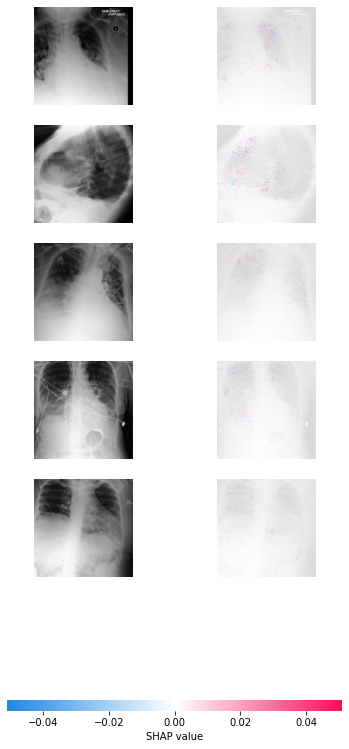

In [63]:
# 1. Extract the SHAP array
if isinstance(shap_values, list):
    sv = np.array(shap_values[0])   # currently (N, 3, 224, 224, 1)
else:
    sv = np.array(shap_values)

print("original sv:", sv.shape)

# 2. Drop the trailing singleton dimension -> (N, 3, 224, 224)
if sv.ndim == 5 and sv.shape[-1] == 1:
    sv = sv[..., 0]
    print("after squeeze:", sv.shape)

# 3. Move channels to the end -> (N, 224, 224, 3)
if sv.ndim == 4 and sv.shape[1] == 3:
    sv = np.transpose(sv, (0, 2, 3, 1))
    print("after transpose:", sv.shape)

# 4. Wrap back in a list (DeepExplainer convention) and plot
shap_values_fixed = [sv]

print("explain_imgs_unnorm:", explain_imgs_unnorm.shape)  # (N, 224, 224, 3)

shap.image_plot(shap_values_fixed, explain_imgs_unnorm)